# 13 — IMDb $D=4$ QOS 真机样本缩放 benchmark

这本 notebook 用固定的 IMDb 派生符号向量

$$
S_{\mathrm{IMDb}}=(+1,-1,-1,-1)
$$

构造六条 Boolean/flat quantum oracle sketching（QOS）线路：

$$
M\in\{4,8,16,32,64,96\}.
$$

它复用 Notebook 09 的 IMDb target 定义和 Notebook 11 的 Quafu-SQC
提交、回执、取回与审计思路，但结果写入独立目录，避免与 full-QSVT
失败记录和旧 backend 结果混在一起。

这是一项**受论文 Figure 3(b) 启发的真机小规模 benchmark**，不是论文原图的
严格复现。论文使用 $N=125,250,500,1000$、随机 Boolean functions、
expected-unitary 数值模拟和每个点 100 次重复；这里固定为 IMDb target、
$N=D=4$，并运行真实有噪声硬件。

本 notebook **不使用 QSVT**。对均匀采样的 Boolean phase oracle，
QOS 本身只需要两个地址量子比特。


In [21]:
# =========================
# 用户通常只需要修改这个配置单元
# =========================

# 可选：dry_run | status | submit | fetch
ACTION = "fetch"

BACKEND = "Shenglian"
COMPILER = "qsteed"

# 为了让不同 M 公平比较，建议固定同一对物理量子比特。
# [34, 40] 是 Notebook 11 的 Shenglian/qsteed 返回线路曾使用的 pair；
# 若当前设备不接受，可改为另一对，或临时设 [] 让编译器选择。
TARGET_QUBITS = [34, 40]

USE_READOUT_CORRECTION = False
OPEN_DD = None                 # None | "XY4" | "CPMG"

M_VALUES = (4, 8, 16, 32, 64, 96)
STREAM_SEED = 20260730
SHOTS = 4096                   # Quafu-SQC 要求 1024 的整数倍

# 六个 M 使用同一条长度 96 IID stream 的不同前缀。
# 这样地址样本相互嵌套，但每个 M 的旋转角仍为 pi*D/M。
STREAM_MODE = "nested_iid"

# P(00) 不受 bitstring 左右顺序影响，所以不需要 one-hot 位序校准。
# 可选 H-only 只用于观察浅线路基线；开启后本批次共 7 条任务。
INCLUDE_H_ONLY_CONTROL = False

# 每次新真机 campaign 请换一个标签，避免与旧任务混淆。
CAMPAIGN_LABEL = "imdb_qos_scaling_pilot_001"

# submit 时必须精确填写下面字符串。
CONFIRM_REAL_SUBMISSION = ""
MAX_TASKS_PER_SUBMISSION = 8
ALLOW_DUPLICATE_SUBMISSION = False

# fetch 默认取回当前 campaign 的全部任务；尚未完成的会安全跳过。
RESULT_TIMEOUT_SECONDS = 60
FORCE_FETCH_NONFINISHED = False


## 1. 论文误差 $\epsilon$ 与本实验 $F_{\rm echo}$ 的区别

论文 Figure 3(b) 的 Boolean-function 曲线使用 expected-unitary proxy。
对 truth table $f:[N]\rightarrow\{0,1\}$，目标 phase oracle 是

$$
O_f=\sum_{j=0}^{N-1}(-1)^{f(j)}|j\rangle\langle j|.
$$

均匀 IID 采样时，代码中第 $j$ 个对角元的期望为

$$
\overline v_j(M)=
\left(
1-\frac1N+
\frac1N e^{i\pi N f(j)/M}
\right)^M.
$$

论文图的误差是

$$
\epsilon_{\rm paper}(M)
=
\left\|\mathbb E[V_M]-O_f\right\|_{\rm op}
=
\max_j\left|\overline v_j(M)-(-1)^{f(j)}\right|.
$$

它是 expected unitary 的最坏坐标算子误差，不是分类错误率，也不是
$1-F$。

本真机线路使用一条已经抽出的固定 stream。若地址 $j$ 出现 $C_j$ 次，则

$$
V_M
=
\sum_j
\exp\left(i\frac{\pi N}{M}C_j f(j)\right)
|j\rangle\langle j|.
$$

离线可以精确计算这条 stream 的

$$
\epsilon_{\rm fixed}
=
\|V_M-O_f\|_{\rm op}.
$$

真机上直接测量的是 echo fidelity：

$$
F_{\rm echo}
=
\left|
\langle +^{\otimes n}|O_f^\dagger V_M|+^{\otimes n}\rangle
\right|^2
=P(00).
$$

$\epsilon$ 看最坏的一个对角元；$F_{\rm echo}$ 看所有地址残余相位的平均，
并再取模平方。因此二者不能互换。这里只把论文 $\epsilon$ 作为离线参考，
硬件主图严格标为 $F_{\rm echo}$。

记号也要区分：

- 论文图例的 $N$ 是 Boolean function 的 domain size；本实验 $N=D=4$；
- 地址量子比特数是 $n=\log_2N=2$；
- $M$ 是经典数据样本数；
- `SHOTS` 是同一静态线路的重复测量次数。


## 2. 环境、路径与 IMDb target

notebook 可以从项目根目录或 `notebooks/` 目录运行。它只读取 Notebook 09
已经生成的 `imdb_d4_target.json`，不会重新训练 IMDb 模型。


In [22]:
import hashlib
import json
import math
import os
import platform
import re
from datetime import datetime, timezone
from getpass import getpass
from importlib.metadata import version
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", "/private/tmp/qos-scaling-mplconfig"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qiskit import qasm2
from qiskit.circuit import Gate
from qiskit.quantum_info import Statevector


def resolve_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        target = (
            candidate
            / "results/imdb_vector_pilot/imdb_d4_target.json"
        )
        if target.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "找不到 Quafu 项目根目录或 IMDb target。"
        "请从项目根目录或 notebooks/ 启动，并先运行 Notebook 09。"
    )


PROJECT_ROOT = resolve_project_root()
TARGET_PATH = (
    PROJECT_ROOT
    / "results/imdb_vector_pilot/imdb_d4_target.json"
)
RESULT_ROOT = PROJECT_ROOT / "results/qos_hardware_scaling"
QASM_DIR = RESULT_ROOT / "qasm"
RAW_RESULT_DIR = RESULT_ROOT / "raw_results"
MANIFEST_PATH = RESULT_ROOT / "manifest.json"
REGISTRY_PATH = RESULT_ROOT / "task_registry.json"
HARDWARE_JSON_PATH = RESULT_ROOT / "hardware_results.json"
HARDWARE_CSV_PATH = RESULT_ROOT / "hardware_results.csv"

for directory in (RESULT_ROOT, QASM_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if ACTION not in {"dry_run", "status", "submit", "fetch"}:
    raise ValueError(f"Unknown ACTION: {ACTION!r}")
if COMPILER not in {None, "quarkcircuit", "qsteed", "qiskit"}:
    raise ValueError(f"Unsupported compiler: {COMPILER!r}")
if OPEN_DD not in {None, "XY4", "CPMG"}:
    raise ValueError("OPEN_DD must be None, 'XY4', or 'CPMG'.")
if STREAM_MODE != "nested_iid":
    raise ValueError("This notebook currently supports nested_iid only.")
if (
    not M_VALUES
    or any(
        not isinstance(item, (int, np.integer))
        or isinstance(item, (bool, np.bool_))
        or int(item) <= 0
        for item in M_VALUES
    )
    or len(set(M_VALUES)) != len(M_VALUES)
):
    raise ValueError("M_VALUES must contain unique positive integers.")
if SHOTS <= 0 or SHOTS % 1024 != 0:
    raise ValueError("SHOTS must be a positive multiple of 1024.")
if TARGET_QUBITS and (
    len(TARGET_QUBITS) != 2
    or len(set(TARGET_QUBITS)) != 2
    or any(int(item) < 0 for item in TARGET_QUBITS)
):
    raise ValueError(
        "TARGET_QUBITS must be [] or two distinct nonnegative integers."
    )
if not re.fullmatch(r"[A-Za-z0-9_-]+", CAMPAIGN_LABEL):
    raise ValueError("CAMPAIGN_LABEL contains unsafe characters.")

target_payload = json.loads(TARGET_PATH.read_text(encoding="utf-8"))
D = int(target_payload["D"])
SIGNS = np.asarray(target_payload["sign_pattern"], dtype=np.int8)
if D != 4 or SIGNS.tolist() != [1, -1, -1, -1]:
    raise AssertionError(
        "This benchmark is frozen to the current IMDb D=4 sign target."
    )
N_ADDRESS = int(round(math.log2(D)))
if 2**N_ADDRESS != D:
    raise AssertionError("D must be a power of two.")
BOOLEAN_F = ((1 - SIGNS) // 2).astype(np.int8)

ENVIRONMENT = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "qiskit": version("qiskit"),
    "quafusqc": version("quafusqc"),
}

print("Project root:", PROJECT_ROOT)
print("Action:", ACTION)
print("Paper notation N = D =", D)
print("Address qubits n =", N_ADDRESS)
print("S_IMDb:", SIGNS.tolist())
print("Boolean f=(1-S)/2:", BOOLEAN_F.tolist())
display(pd.Series(ENVIRONMENT, name="version").to_frame())


Project root: /Users/tangzhi/Desktop/Quafu
Action: fetch
Paper notation N = D = 4
Address qubits n = 2
S_IMDb: [1, -1, -1, -1]
Boolean f=(1-S)/2: [0, 1, 1, 1]


,version
python,3.13.7
numpy,2.3.3
pandas,2.3.2
qiskit,2.5.1
quafusqc,3.3.9


## 3. 生成六条静态 QASM 并做 statevector 审计

每个经典样本只对对应地址施加一个小 projector phase。静态 QASM 将这条
sample stream 展开，因此更大的 $M$ 会直接带来更深的真机线路。

六个 $M$ 使用同一条长度 96 的 IID 地址流的不同前缀。这样能减少“完全不同
随机流”的额外差异，但单条轨迹仍然不能代替论文的 100 次重复平均。


In [23]:
def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(f"Cannot encode {type(value).__name__}")


def write_json_atomic(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(
            payload,
            indent=2,
            ensure_ascii=False,
            default=json_default,
        ),
        encoding="utf-8",
    )
    temporary.replace(path)


def sha256_text(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def stream_sha256(stream):
    return hashlib.sha256(
        np.asarray(stream, dtype=np.int64).tobytes()
    ).hexdigest()


def qasm_header():
    return [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        "qreg q[2];",
        "creg c[2];",
    ]


def append_projector_phase(lines, address, angle):
    zero_bits = [
        bit
        for bit in range(N_ADDRESS)
        if ((int(address) >> bit) & 1) == 0
    ]
    for bit in zero_bits:
        lines.append(f"x q[{bit}];")

    half_angle = float(angle) / 2
    lines.extend(
        [
            f"u1({half_angle:.16g}) q[0];",
            "cx q[0],q[1];",
            f"u1({-half_angle:.16g}) q[1];",
            "cx q[0],q[1];",
            f"u1({half_angle:.16g}) q[1];",
        ]
    )
    for bit in reversed(zero_bits):
        lines.append(f"x q[{bit}];")
    lines.append("barrier q;")


def build_echo_qasm(stream):
    stream = np.asarray(stream, dtype=np.int64)
    if len(stream) == 0:
        raise ValueError("stream must be nonempty")
    theta = np.pi * D / len(stream)
    lines = qasm_header()
    lines.extend(["h q[0];", "h q[1];", "barrier q;"])

    for address in stream:
        if BOOLEAN_F[int(address)] == 1:
            append_projector_phase(lines, int(address), theta)
        else:
            lines.append("barrier q;")

    # Apply the exact target oracle inverse before the final Hadamards.
    lines.append("barrier q;")
    for address, value in enumerate(BOOLEAN_F):
        if int(value) == 1:
            append_projector_phase(lines, address, -np.pi)

    lines.extend(
        [
            "barrier q;",
            "h q[0];",
            "h q[1];",
            "measure q[0] -> c[0];",
            "measure q[1] -> c[1];",
        ]
    )
    return "\n".join(lines) + "\n"


def build_h_only_qasm():
    lines = qasm_header()
    lines.extend(
        [
            "h q[0];",
            "h q[1];",
            "barrier q;",
            "h q[0];",
            "h q[1];",
            "measure q[0] -> c[0];",
            "measure q[1] -> c[1];",
        ]
    )
    return "\n".join(lines) + "\n"


def paper_expected_operator_error(m_data):
    theta = np.pi * D / m_data
    expected_diag = (
        1
        - 1 / D
        + np.exp(1j * theta * BOOLEAN_F) / D
    ) ** m_data
    target_diag = np.exp(1j * np.pi * BOOLEAN_F)
    return float(np.max(np.abs(expected_diag - target_diag)))


def fixed_stream_metrics(stream):
    stream = np.asarray(stream, dtype=np.int64)
    m_data = len(stream)
    counts = np.bincount(stream, minlength=D)
    theta = np.pi * D / m_data
    sampled_diag = np.exp(1j * theta * counts * BOOLEAN_F)
    target_diag = np.exp(1j * np.pi * BOOLEAN_F)
    residual = sampled_diag * np.conj(target_diag)
    return {
        "stream_counts": counts.tolist(),
        "fixed_operator_error": float(
            np.max(np.abs(sampled_diag - target_diag))
        ),
        "ideal_F_echo_fixed": float(
            abs(np.mean(residual)) ** 2
        ),
    }


def expected_iid_F_echo(m_data):
    k_negative = int(np.sum(BOOLEAN_F))
    k_positive = D - k_negative
    theta = np.pi * D / m_data
    a = (
        1 - 1 / D + np.exp(1j * theta) / D
    ) ** m_data
    b = (
        1 + 2 * (np.cos(theta) - 1) / D
    ) ** m_data
    return float(
        (
            k_positive**2
            + k_negative
            + k_negative * (k_negative - 1) * b
            - 2 * k_negative * k_positive * np.real(a)
        )
        / D**2
    )


rng = np.random.default_rng(STREAM_SEED)
master_stream = rng.integers(
    0,
    D,
    size=max(M_VALUES),
    dtype=np.int64,
)

manifest = []
circuits_by_m = {}
for m_data in sorted(M_VALUES):
    stream = master_stream[:m_data].copy()
    qasm_text = build_echo_qasm(stream)
    circuit = qasm2.loads(qasm_text)
    bare = circuit.remove_final_measurements(inplace=False)
    state = np.asarray(Statevector.from_instruction(bare).data)
    metrics = fixed_stream_metrics(stream)
    if not np.isclose(
        abs(state[0]) ** 2,
        metrics["ideal_F_echo_fixed"],
        atol=1e-10,
    ):
        raise AssertionError(f"Statevector mismatch for M={m_data}")

    operations = {
        str(key): int(value)
        for key, value in circuit.count_ops().items()
    }
    experiment_id = f"imdb_qos_scaling_M{m_data}_nested_r0"
    qasm_path = QASM_DIR / f"{experiment_id}.qasm"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    entry = {
        "experiment_id": experiment_id,
        "family": "imdb_boolean_qos_scaling",
        "target": "S_IMDB",
        "D": D,
        "N_paper": D,
        "n_address_qubits": N_ADDRESS,
        "n_total_qubits": 2,
        "sign_vector": SIGNS.tolist(),
        "boolean_truth_table": BOOLEAN_F.tolist(),
        "M_data": int(m_data),
        "stream_mode": STREAM_MODE,
        "stream_seed": STREAM_SEED,
        "stream": stream.tolist(),
        "stream_counts": metrics["stream_counts"],
        "stream_sha256": stream_sha256(stream),
        "paper_expected_operator_error": (
            paper_expected_operator_error(m_data)
        ),
        "fixed_operator_error": metrics[
            "fixed_operator_error"
        ],
        "ideal_F_echo_fixed": metrics[
            "ideal_F_echo_fixed"
        ],
        "analytic_E_iid_F_echo": expected_iid_F_echo(m_data),
        "S_shots": SHOTS,
        "logical_depth": circuit.depth(),
        "logical_cx": operations.get("cx", 0),
        "logical_h": operations.get("h", 0),
        "logical_u1": operations.get("u1", 0),
        "qasm_path": str(qasm_path.relative_to(PROJECT_ROOT)),
        "qasm_sha256": sha256_text(qasm_text),
    }
    manifest.append(entry)
    circuits_by_m[int(m_data)] = circuit

if INCLUDE_H_ONLY_CONTROL:
    qasm_text = build_h_only_qasm()
    circuit = qasm2.loads(qasm_text)
    qasm_path = QASM_DIR / "imdb_qos_scaling_h_only.qasm"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    operations = {
        str(key): int(value)
        for key, value in circuit.count_ops().items()
    }
    manifest.insert(
        0,
        {
            "experiment_id": "imdb_qos_scaling_h_only",
            "family": "h_only_control",
            "target": "control",
            "D": D,
            "N_paper": D,
            "n_address_qubits": N_ADDRESS,
            "n_total_qubits": 2,
            "M_data": 0,
            "stream_mode": "none",
            "stream": [],
            "stream_counts": [0] * D,
            "paper_expected_operator_error": 0.0,
            "fixed_operator_error": 0.0,
            "ideal_F_echo_fixed": 1.0,
            "analytic_E_iid_F_echo": 1.0,
            "S_shots": SHOTS,
            "logical_depth": circuit.depth(),
            "logical_cx": operations.get("cx", 0),
            "logical_h": operations.get("h", 0),
            "logical_u1": operations.get("u1", 0),
            "qasm_path": str(qasm_path.relative_to(PROJECT_ROOT)),
            "qasm_sha256": sha256_text(qasm_text),
        },
    )

write_json_atomic(MANIFEST_PATH, manifest)
manifest_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in entry.items()
            if key not in {"stream"}
        }
        for entry in manifest
    ]
)
manifest_frame.to_csv(
    RESULT_ROOT / "manifest.csv", index=False
)

display(
    manifest_frame[
        [
            "experiment_id",
            "M_data",
            "stream_counts",
            "paper_expected_operator_error",
            "fixed_operator_error",
            "ideal_F_echo_fixed",
            "analytic_E_iid_F_echo",
            "logical_cx",
            "logical_depth",
        ]
    ]
)
print("Manifest:", MANIFEST_PATH)


,experiment_id,M_data,stream_counts,paper_expected_operator_error,fixed_operator_error,ideal_F_echo_fixed,analytic_E_iid_F_echo,logical_cx,logical_depth
0,imdb_qos_scaling_M4_nested_r0,4,"[0, 1, 0, 3]",1.062500,2.000000,0.250000,0.226562,14,41
1,imdb_qos_scaling_M8_nested_r0,8,"[2, 1, 2, 3]",0.875191,1.414214,0.250000,0.299713,18,53
2,imdb_qos_scaling_M16_nested_r0,16,"[4, 3, 5, 4]",0.610888,0.765367,0.728553,0.426437,30,88
3,imdb_qos_scaling_M32_nested_r0,32,"[9, 8, 9, 6]",0.371631,0.765367,0.830582,0.594159,52,152
4,imdb_qos_scaling_M64_nested_r0,64,"[21, 19, 10, 14]",0.206698,1.111140,0.650702,0.749686,92,264
5,imdb_qos_scaling_M96_nested_r0,96,"[28, 28, 16, 24]",0.142968,1.000000,0.716506,0.819887,142,404


Manifest: /Users/tangzhi/Desktop/Quafu/results/qos_hardware_scaling/manifest.json


### 代表性线路图

下面显示 $M=8$ 的完整 echo 线路。中间重复的 projector-phase blocks 就是逐个
处理经典样本；末尾是精确 $O_f^\dagger$ 和 Hadamard echo readout。


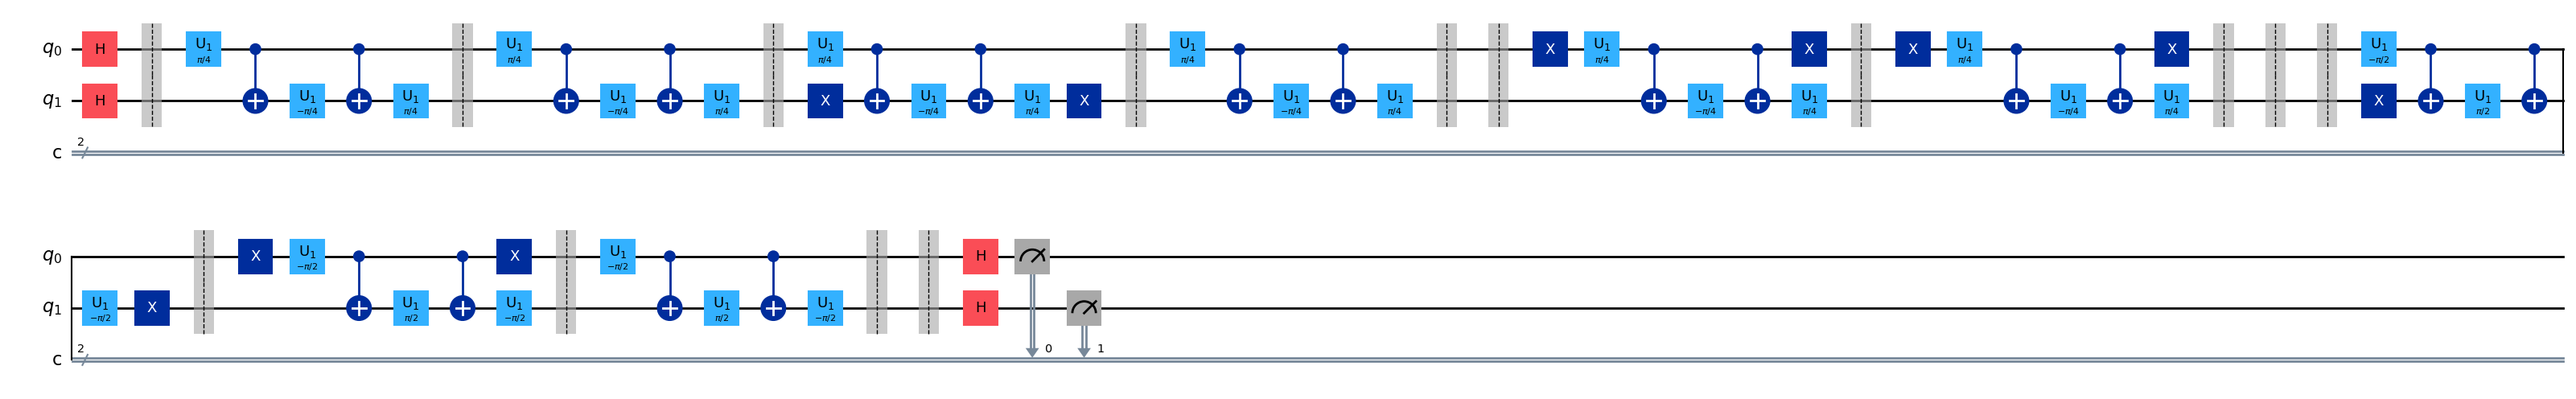

Saved: /Users/tangzhi/Desktop/Quafu/assets/circuits/imdb-qos-scaling-M8.png


In [24]:
representative_m = 8 if 8 in circuits_by_m else min(circuits_by_m)
representative_circuit = circuits_by_m[representative_m]
try:
    figure = representative_circuit.draw(
        output="mpl",
        fold=48,
        idle_wires=False,
    )
    circuit_path = (
        PROJECT_ROOT
        / "assets/circuits/imdb-qos-scaling-M8.png"
    )
    circuit_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(circuit_path, dpi=180, bbox_inches="tight")
    display(figure)
    print("Saved:", circuit_path)
except Exception as exc:
    print("mpl circuit drawing unavailable:", exc)
    print(representative_circuit.draw(output="text", fold=120))


## 4. 离线 Figure-3(b)-style 参考与硬件压力

左图的两条曲线都来自离线计算：

- `expected-unitary ε` 才是论文开源 benchmark 的定义；
- `this fixed stream ε` 是本批六条具体 QASM 的无噪声最坏坐标误差。

中图是 echo fidelity；右图是静态展开线路的逻辑 CX 数。硬件噪声尚未进入这些图。


Saved: /Users/tangzhi/Desktop/Quafu/results/qos_hardware_scaling/offline_qos_scaling_reference.png


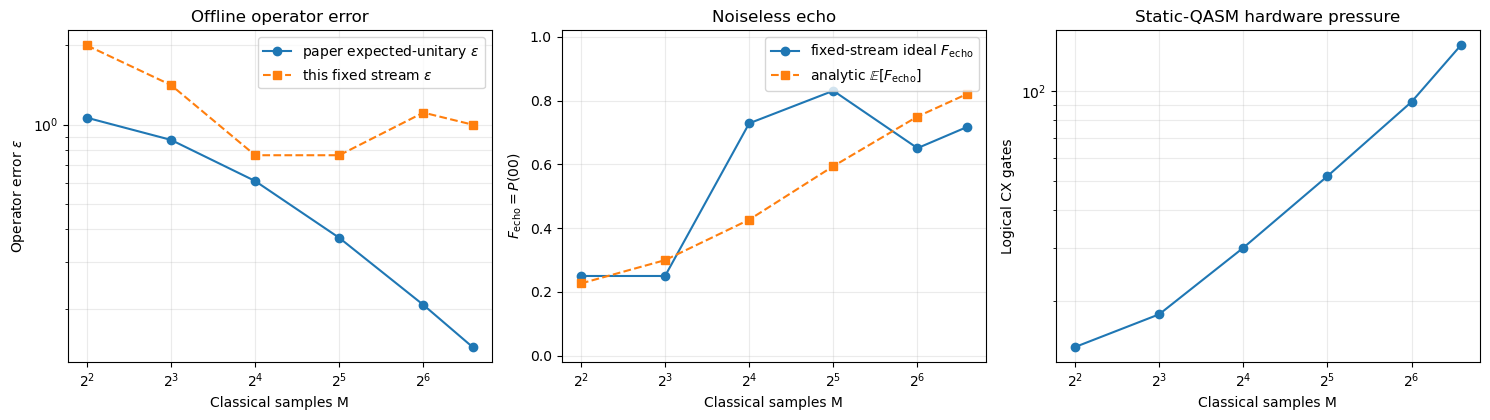

In [25]:
scaling_frame = manifest_frame.loc[
    manifest_frame["M_data"] > 0
].sort_values("M_data")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

axes[0].plot(
    scaling_frame["M_data"],
    scaling_frame["paper_expected_operator_error"],
    "o-",
    label=r"paper expected-unitary $\epsilon$",
)
axes[0].plot(
    scaling_frame["M_data"],
    scaling_frame["fixed_operator_error"],
    "s--",
    label=r"this fixed stream $\epsilon$",
)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Classical samples M")
axes[0].set_ylabel(r"Operator error $\epsilon$")
axes[0].set_title("Offline operator error")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(
    scaling_frame["M_data"],
    scaling_frame["ideal_F_echo_fixed"],
    "o-",
    label=r"fixed-stream ideal $F_{\rm echo}$",
)
axes[1].plot(
    scaling_frame["M_data"],
    scaling_frame["analytic_E_iid_F_echo"],
    "s--",
    label=r"analytic $\mathbb{E}[F_{\rm echo}]$",
)
axes[1].set_xscale("log", base=2)
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlabel("Classical samples M")
axes[1].set_ylabel(r"$F_{\rm echo}=P(00)$")
axes[1].set_title("Noiseless echo")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(
    scaling_frame["M_data"],
    scaling_frame["logical_cx"],
    "o-",
)
axes[2].set_xscale("log", base=2)
axes[2].set_yscale("log")
axes[2].set_xlabel("Classical samples M")
axes[2].set_ylabel("Logical CX gates")
axes[2].set_title("Static-QASM hardware pressure")
axes[2].grid(True, which="both", alpha=0.25)

fig.tight_layout()
offline_plot_path = (
    RESULT_ROOT / "offline_qos_scaling_reference.png"
)
fig.savefig(offline_plot_path, dpi=180, bbox_inches="tight")
print("Saved:", offline_plot_path)
plt.show()


## 5. 冻结运行计划并进行提交前审计

默认一次选择六条 $M$ 线路。`INCLUDE_H_ONLY_CONTROL=True` 时额外选择一条
浅线路 control。所有 QASM 在联网之前重新核对 hash、qubit、classical bit
和 measurement mapping。


In [26]:
entry_by_id = {
    entry["experiment_id"]: entry for entry in manifest
}
run_plan = []
for entry in manifest:
    m_data = int(entry["M_data"])
    suffix = "h_only" if m_data == 0 else f"M{m_data}"
    run_plan.append(
        {
            "enabled": True,
            "run_label": f"{CAMPAIGN_LABEL}_{suffix}",
            "experiment_id": entry["experiment_id"],
            "compiler": COMPILER,
        }
    )

audit_rows = []
for item in run_plan:
    entry = entry_by_id[item["experiment_id"]]
    qasm_path = PROJECT_ROOT / entry["qasm_path"]
    qasm_text = qasm_path.read_text(encoding="utf-8")
    observed_hash = sha256_text(qasm_text)
    parse_error = ""
    measurement_map = []
    try:
        circuit = qasm2.loads(qasm_text)
        for instruction in circuit.data:
            if instruction.operation.name == "measure":
                q_index = circuit.find_bit(
                    instruction.qubits[0]
                ).index
                c_index = circuit.find_bit(
                    instruction.clbits[0]
                ).index
                measurement_map.append((q_index, c_index))
        measurement_map = sorted(measurement_map)
        schema_ok = (
            circuit.num_qubits == 2
            and circuit.num_clbits == 2
            and measurement_map == [(0, 0), (1, 1)]
        )
    except Exception as exc:
        schema_ok = False
        parse_error = f"{type(exc).__name__}: {exc}"
    audit_rows.append(
        {
            "enabled": item["enabled"],
            "run_label": item["run_label"],
            "experiment_id": item["experiment_id"],
            "M_data": entry["M_data"],
            "compiler": item["compiler"],
            "shots": entry["S_shots"],
            "qasm_sha256_ok": (
                observed_hash == entry["qasm_sha256"]
            ),
            "schema_ok": schema_ok,
            "measurement_map": measurement_map,
            "parse_error": parse_error,
        }
    )

audit_frame = pd.DataFrame(audit_rows)
audit_frame["audit_pass"] = (
    audit_frame["qasm_sha256_ok"]
    & audit_frame["schema_ok"]
)
if not bool(audit_frame["audit_pass"].all()):
    display(audit_frame.loc[~audit_frame["audit_pass"]])
    raise AssertionError("At least one QASM failed offline audit.")
if int(audit_frame["enabled"].sum()) > MAX_TASKS_PER_SUBMISSION:
    raise ValueError(
        "Enabled tasks exceed MAX_TASKS_PER_SUBMISSION."
    )
if len(audit_frame["run_label"]) != len(
    set(audit_frame["run_label"])
):
    raise ValueError("Duplicate run labels.")

audit_frame.to_csv(
    RESULT_ROOT / "offline_audit.csv", index=False
)
write_json_atomic(
    RESULT_ROOT / "offline_audit.json",
    {
        "audited_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "network_used": False,
        "hardware_submitted": False,
        "campaign_label": CAMPAIGN_LABEL,
        "backend": BACKEND,
        "compiler": COMPILER,
        "target_qubits": TARGET_QUBITS,
        "environment": ENVIRONMENT,
        "rows": audit_rows,
    },
)
display(audit_frame)
print(
    "Offline audit PASS; enabled tasks:",
    int(audit_frame["enabled"].sum()),
)


,enabled,run_label,experiment_id,M_data,compiler,shots,qasm_sha256_ok,schema_ok,measurement_map,parse_error,audit_pass
0,True,imdb_qos_scaling_pilot_001_M4,imdb_qos_scaling_M4_nested_r0,4,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True
1,True,imdb_qos_scaling_pilot_001_M8,imdb_qos_scaling_M8_nested_r0,8,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True
2,True,imdb_qos_scaling_pilot_001_M16,imdb_qos_scaling_M16_nested_r0,16,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True
3,True,imdb_qos_scaling_pilot_001_M32,imdb_qos_scaling_M32_nested_r0,32,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True
4,True,imdb_qos_scaling_pilot_001_M64,imdb_qos_scaling_M64_nested_r0,64,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True
5,True,imdb_qos_scaling_pilot_001_M96,imdb_qos_scaling_M96_nested_r0,96,qsteed,4096,True,True,"[(0, 0), (1, 1)]",,True


Offline audit PASS; enabled tasks: 6


## 6. 建立可选网络会话并查询队列

只有 `status`、`submit` 或 `fetch` 会读取 token。可以通过环境变量
`QPU_API_TOKEN` 提供；否则 notebook 会用隐藏输入框询问。


In [27]:
NETWORK_ACTIONS = {"status", "submit", "fetch"}
FINISHED_STATES = {"finished", "completed", "success"}
FAILED_STATES = {
    "failed", "error", "cancelled", "canceled", "deleted"
}


def normalized_status(value):
    return str(value).strip().lower()


def valid_task_id(value):
    return (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) > 0
    )


def backend_value_is_available(value):
    return (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) >= 0
    ) or (
        isinstance(value, str)
        and value.strip().lower()
        in {"online", "available", "idle"}
    )


task_manager = None
live_backend_status = None
if ACTION in NETWORK_ACTIONS:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)

if ACTION in {"status", "submit"}:
    live_backend_status = task_manager.status()
    print("Live backend status:", live_backend_status)
    if not isinstance(live_backend_status, dict):
        raise RuntimeError(
            "Fail-closed: backend status is not a mapping."
        )
    backend_value = live_backend_status.get(BACKEND)
    if not backend_value_is_available(backend_value):
        raise RuntimeError(
            f"Fail-closed: unexpected {BACKEND} state "
            f"{backend_value!r}."
        )
    RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)
    write_json_atomic(
        RAW_RESULT_DIR
        / (
            "backend_status_"
            + datetime.now(timezone.utc).strftime(
                "%Y%m%dT%H%M%SZ"
            )
            + ".json"
        ),
        live_backend_status,
    )
elif ACTION == "dry_run":
    print("Dry run: no token read and no network request.")

if ACTION == "status":
    print(
        f"{BACKEND} queue value:",
        live_backend_status.get(BACKEND),
    )


## 7. 任务 registry、批量提交与状态检查

Quafu-SQC 的 `run(task)` 是异步的。一次运行此单元会依次提交全部已启用线路，
每获得一个 task ID 就立即写入本地 registry；不需要等待前一条执行完成。


In [28]:
def read_registry():
    if not REGISTRY_PATH.exists():
        return []
    payload = json.loads(
        REGISTRY_PATH.read_text(encoding="utf-8")
    )
    if not isinstance(payload, list):
        raise ValueError("Task registry must be a list.")
    return payload


def task_fingerprint(record):
    return json.dumps(
        {
            "run_label": record["run_label"],
            "experiment_id": record["experiment_id"],
            "backend": record["backend"],
            "compiler": record["compiler"],
            "correct": record["correct"],
            "open_dd": record["open_dd"],
            "target_qubits": record["target_qubits"],
        },
        sort_keys=True,
    )


submitted_records = []
if ACTION == "submit":
    if CONFIRM_REAL_SUBMISSION != "RUN_QUAFU_HARDWARE":
        raise ValueError(
            "Set CONFIRM_REAL_SUBMISSION exactly to "
            "'RUN_QUAFU_HARDWARE'."
        )
    enabled_plan = [
        item for item in run_plan if item["enabled"]
    ]
    if not enabled_plan:
        raise ValueError("No task is enabled.")
    if len(enabled_plan) > MAX_TASKS_PER_SUBMISSION:
        raise ValueError("Too many enabled tasks.")

    registry = read_registry()
    existing_fingerprints = {
        task_fingerprint(record)
        for record in registry
        if valid_task_id(record.get("task_id"))
    }

    for plan_item in enabled_plan:
        entry = entry_by_id[plan_item["experiment_id"]]
        candidate = {
            "run_label": plan_item["run_label"],
            "experiment_id": plan_item["experiment_id"],
            "backend": BACKEND,
            "compiler": plan_item["compiler"],
            "correct": bool(USE_READOUT_CORRECTION),
            "open_dd": OPEN_DD,
            "target_qubits": [
                int(item) for item in TARGET_QUBITS
            ],
        }
        fingerprint = task_fingerprint(candidate)
        if (
            fingerprint in existing_fingerprints
            and not ALLOW_DUPLICATE_SUBMISSION
        ):
            print(
                "Already registered; safely skipped:",
                plan_item["run_label"],
            )
            continue

        qasm_path = PROJECT_ROOT / entry["qasm_path"]
        qasm_text = qasm_path.read_text(encoding="utf-8")
        if sha256_text(qasm_text) != entry["qasm_sha256"]:
            raise RuntimeError(
                f"QASM hash mismatch: {entry['experiment_id']}"
            )

        timestamp = datetime.now(timezone.utc)
        task_name = (
            f"qos_{plan_item['run_label']}_"
            f"{timestamp.strftime('%m%dT%H%M%S')}"
        )[:80]
        task = {
            "chip": BACKEND,
            "name": task_name,
            "circuit": qasm_text,
            "shots": int(entry["S_shots"]),
            "compile": True,
            "options": {
                "compiler": plan_item["compiler"],
                "correct": bool(USE_READOUT_CORRECTION),
                "open_dd": OPEN_DD,
                "target_qubits": [
                    int(item) for item in TARGET_QUBITS
                ],
            },
        }
        task_id = task_manager.run(task)
        if not valid_task_id(task_id):
            raise RuntimeError(
                "Submission did not return a positive task id: "
                f"{task_id!r}"
            )

        record = {
            **candidate,
            "task_id": int(task_id),
            "task_name": task_name,
            "M_data": int(entry["M_data"]),
            "shots": int(entry["S_shots"]),
            "qasm_path": entry["qasm_path"],
            "qasm_sha256": entry["qasm_sha256"],
            "submitted_at_utc": timestamp.isoformat(),
            "submission_status": "submitted",
            "environment": ENVIRONMENT,
        }
        RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)
        receipt_path = (
            RAW_RESULT_DIR
            / f"receipt_{plan_item['run_label']}_{task_id}.json"
        )
        write_json_atomic(receipt_path, record)
        record["receipt_path"] = str(
            receipt_path.relative_to(PROJECT_ROOT)
        )
        registry.append(record)
        write_json_atomic(REGISTRY_PATH, registry)
        existing_fingerprints.add(fingerprint)
        submitted_records.append(record)
        print(
            "Submitted:",
            plan_item["run_label"],
            "task_id=",
            int(task_id),
        )
else:
    print("Submission inactive for ACTION =", ACTION)


if ACTION == "status" and REGISTRY_PATH.exists():
    registry = [
        record
        for record in read_registry()
        if str(record.get("run_label", "")).startswith(
            CAMPAIGN_LABEL + "_"
        )
    ]
    status_rows = []
    for record in registry:
        task_id = int(record["task_id"])
        task_status = task_manager.status(task_id)
        status_rows.append(
            {
                "run_label": record["run_label"],
                "M_data": record.get("M_data"),
                "task_id": task_id,
                "status": task_status,
            }
        )
    if status_rows:
        display(pd.DataFrame(status_rows))
    else:
        print("No registry task for current campaign.")


Submission inactive for ACTION = fetch


## 8. 批量 fetch 与结果解析

`ACTION="fetch"` 时会读取当前 `CAMPAIGN_LABEL` 下的全部 registry 任务。
未完成任务只记录状态，不调用结果端点；稍后再次 `Run All` 即可继续取回。

由于目标事件是字符串 `00`，左右 bit order 都映射到同一个 `00`，所以这个
指标不依赖 Notebook 11 的 one-hot 校准。


In [29]:
def wilson_interval(successes, total, z=1.959963984540054):
    successes = float(successes)
    total = float(total)
    if total <= 0 or successes < 0 or successes > total:
        return (np.nan, np.nan)
    proportion = successes / total
    denominator = 1 + z * z / total
    center = (
        proportion + z * z / (2 * total)
    ) / denominator
    half_width = (
        z
        * math.sqrt(
            proportion * (1 - proportion) / total
            + z * z / (4 * total * total)
        )
        / denominator
    )
    return (
        max(0.0, center - half_width),
        min(1.0, center + half_width),
    )


def parse_raw_counts(counts, expected_shots):
    if not isinstance(counts, dict) or not counts:
        return {
            "parse_reason": "missing_counts",
            "raw_F_echo": np.nan,
            "raw_F_echo_ci_low": np.nan,
            "raw_F_echo_ci_high": np.nan,
            "shots_observed": 0,
            "shots_match_manifest": False,
            "raw_distribution": {},
        }
    cleaned = {}
    for raw_bits, raw_value in counts.items():
        bits = str(raw_bits).replace(" ", "")
        if len(bits) != 2 or set(bits) - {"0", "1"}:
            raise ValueError(f"Invalid bitstring: {raw_bits!r}")
        if (
            isinstance(raw_value, bool)
            or not isinstance(raw_value, (int, np.integer))
            or int(raw_value) < 0
        ):
            raise ValueError(
                f"Invalid raw count for {bits}: {raw_value!r}"
            )
        cleaned[bits] = cleaned.get(bits, 0) + int(raw_value)
    total = int(sum(cleaned.values()))
    if total <= 0:
        raise ValueError("Counts total must be positive.")
    successes = int(cleaned.get("00", 0))
    raw_f = successes / total
    low, high = wilson_interval(successes, total)
    return {
        "parse_reason": "ok",
        "raw_F_echo": raw_f,
        "raw_F_echo_ci_low": low,
        "raw_F_echo_ci_high": high,
        "raw_echo_infidelity": 1 - raw_f,
        "shots_observed": total,
        "shots_match_manifest": total == int(expected_shots),
        "raw_distribution": cleaned,
    }


def returned_qasm_metrics(qasm_text):
    empty = {
        "returned_depth": np.nan,
        "returned_two_qubit_gates": np.nan,
        "returned_two_qubit_depth": np.nan,
        "returned_swap_gates": np.nan,
        "returned_num_qubits": np.nan,
        "returned_ops": {},
    }
    if not isinstance(qasm_text, str) or not qasm_text:
        return {
            **empty,
            "returned_qasm_parse_reason": "missing",
        }
    normalized = re.sub(
        r"(?m)^(\s*)u\(",
        r"\1u3(",
        qasm_text,
    )
    try:
        circuit = qasm2.loads(normalized)
    except Exception as exc:
        return {
            **empty,
            "returned_qasm_parse_reason":
                f"parse_error:{type(exc).__name__}:{exc}",
        }
    gates = [
        item
        for item in circuit.data
        if isinstance(item.operation, Gate)
    ]
    operations = {
        str(key): int(value)
        for key, value in circuit.count_ops().items()
    }
    return {
        "returned_depth": circuit.depth(),
        "returned_two_qubit_gates": sum(
            int(item.operation.num_qubits == 2)
            for item in gates
        ),
        "returned_two_qubit_depth": circuit.depth(
            filter_function=lambda item: (
                isinstance(item.operation, Gate)
                and item.operation.num_qubits == 2
            )
        ),
        "returned_swap_gates": int(
            operations.get("swap", 0)
        ),
        "returned_num_qubits": circuit.num_qubits,
        "returned_ops": operations,
        "returned_qasm_parse_reason": "ok",
    }


# Offline parser self-tests.
mock = parse_raw_counts(
    {"00": 900, "01": 40, "10": 40, "11": 44},
    1024,
)
assert np.isclose(mock["raw_F_echo"], 900 / 1024)
assert mock["shots_match_manifest"]
print("Counts parser self-test PASS.")


new_result_rows = []
if ACTION == "fetch":
    registry = [
        record
        for record in read_registry()
        if str(record.get("run_label", "")).startswith(
            CAMPAIGN_LABEL + "_"
        )
        and valid_task_id(record.get("task_id"))
    ]
    if not registry:
        raise ValueError(
            "No registry task for current CAMPAIGN_LABEL."
        )
    RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)

    for record in registry:
        task_id = int(record["task_id"])
        entry = entry_by_id[record["experiment_id"]]
        status_value = task_manager.status(task_id)
        state = normalized_status(status_value)
        base_row = {
            "fetched_at_utc": datetime.now(
                timezone.utc
            ).isoformat(),
            "campaign_label": CAMPAIGN_LABEL,
            "run_label": record["run_label"],
            "experiment_id": record["experiment_id"],
            "task_id": task_id,
            "backend": record.get("backend", BACKEND),
            "compiler": record["compiler"],
            "target_qubits_requested": record.get(
                "target_qubits", []
            ),
            "task_status_query": status_value,
            "M_data": int(entry["M_data"]),
            "paper_expected_operator_error": entry[
                "paper_expected_operator_error"
            ],
            "fixed_operator_error": entry[
                "fixed_operator_error"
            ],
            "ideal_F_echo_fixed": entry[
                "ideal_F_echo_fixed"
            ],
            "analytic_E_iid_F_echo": entry[
                "analytic_E_iid_F_echo"
            ],
            "logical_cx": entry["logical_cx"],
            "logical_depth": entry["logical_depth"],
        }
        if (
            state not in FINISHED_STATES
            and not FORCE_FETCH_NONFINISHED
        ):
            print(
                "Not finished; skipped result endpoint:",
                task_id,
                status_value,
            )
            new_result_rows.append(
                {
                    **base_row,
                    "result_status": None,
                    "fetch_reason":
                        f"nonfinished_status:{status_value!r}",
                }
            )
            continue

        result = task_manager.result(
            task_id,
            timeout=float(RESULT_TIMEOUT_SECONDS),
        )
        if not isinstance(result, dict):
            result = {
                "status": "invalid_result_type",
                "finished": False,
                "error": repr(result),
            }
        raw_path = (
            RAW_RESULT_DIR
            / f"result_{record['run_label']}_{task_id}.json"
        )
        write_json_atomic(raw_path, result)

        returned_qasm = result.get("transpiled", "")
        returned_qasm_path = None
        if isinstance(returned_qasm, str) and returned_qasm:
            returned_qasm_path = (
                RAW_RESULT_DIR
                / f"returned_{record['run_label']}_{task_id}.qasm"
            )
            returned_qasm_path.write_text(
                returned_qasm, encoding="utf-8"
            )

        terminal = (
            normalized_status(result.get("status"))
            in FINISHED_STATES
        )
        has_counts = (
            isinstance(result.get("count"), dict)
            and bool(result.get("count"))
        )
        parsed = parse_raw_counts(
            result.get("count") or {},
            entry["S_shots"],
        )
        new_result_rows.append(
            {
                **base_row,
                "result_status": result.get("status"),
                "result_finished": result.get("finished"),
                "result_error": result.get("error", ""),
                "returned_task_id": result.get("tid"),
                "task_id_matches": (
                    result.get("tid") is None
                    or int(result.get("tid")) == task_id
                ),
                "raw_result_path": str(
                    raw_path.relative_to(PROJECT_ROOT)
                ),
                "returned_qasm_path": (
                    str(
                        returned_qasm_path.relative_to(
                            PROJECT_ROOT
                        )
                    )
                    if returned_qasm_path
                    else None
                ),
                "fetch_reason": (
                    "ok"
                    if terminal and has_counts
                    else "nonterminal_or_empty_result_payload"
                ),
                **parsed,
                **returned_qasm_metrics(returned_qasm),
            }
        )

    existing_rows = []
    if HARDWARE_JSON_PATH.exists():
        payload = json.loads(
            HARDWARE_JSON_PATH.read_text(encoding="utf-8")
        )
        if isinstance(payload, list):
            existing_rows = payload
    combined = {
        int(item["task_id"]): item
        for item in existing_rows
        if valid_task_id(item.get("task_id"))
    }
    for item in new_result_rows:
        combined[int(item["task_id"])] = item
    combined_rows = list(combined.values())
    write_json_atomic(HARDWARE_JSON_PATH, combined_rows)
    pd.DataFrame(combined_rows).to_csv(
        HARDWARE_CSV_PATH, index=False
    )
    print("Saved result rows:", len(combined_rows))
else:
    print("Fetch inactive for ACTION =", ACTION)


Counts parser self-test PASS.
Saved result rows: 6


## 9. 真机结果图

左图仍是离线算子误差；右图才包含真实硬件的 $F_{\rm echo}$ 和 95% Wilson
区间。这样不会把 $1-F$ 错标成论文 $\epsilon$。


Saved: /Users/tangzhi/Desktop/Quafu/results/qos_hardware_scaling/imdb_qos_scaling_pilot_001_hardware_scaling.png


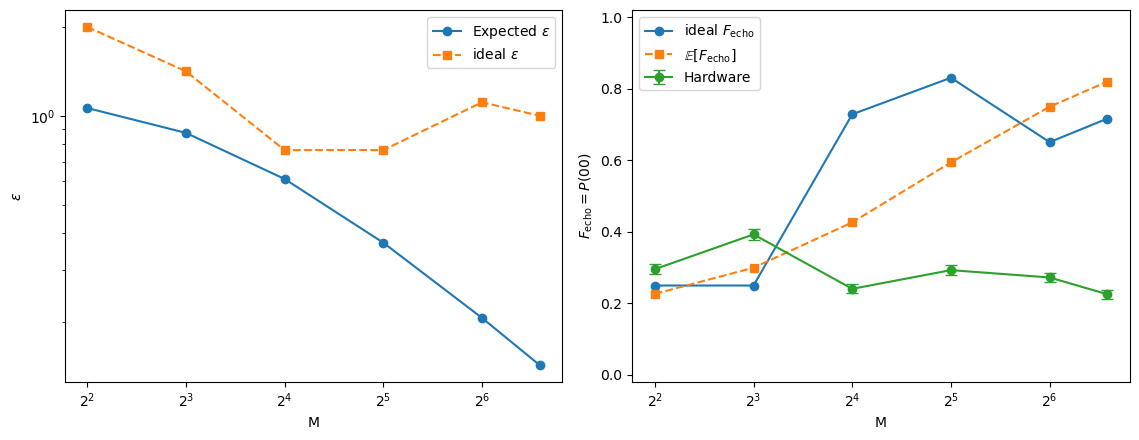

,M_data,task_id,result_status,ideal_F_echo_fixed,raw_F_echo,raw_F_echo_ci_low,raw_F_echo_ci_high,logical_cx,returned_two_qubit_gates,returned_two_qubit_depth,returned_swap_gates
0,4,2607310519564016525,Finished,0.250000,0.295654,0.281876,0.309816,14,14,14,0
1,8,2607310519568445963,Finished,0.250000,0.392822,0.377973,0.407872,18,18,18,0
2,16,2607310519572889762,Finished,0.728553,0.240723,0.227877,0.254054,30,30,30,0
3,32,2607310519577428992,Finished,0.830582,0.292969,0.279230,0.307095,52,52,52,0
4,64,2607310519581922037,Finished,0.650702,0.272461,0.259044,0.286304,92,92,92,0
5,96,2607310519586360220,Finished,0.716506,0.225586,0.213046,0.238640,142,142,142,0


In [34]:
hardware_frame = pd.DataFrame()
if HARDWARE_JSON_PATH.exists():
    payload = json.loads(
        HARDWARE_JSON_PATH.read_text(encoding="utf-8")
    )
    hardware_frame = pd.DataFrame(payload)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

axes[0].plot(
    scaling_frame["M_data"],
    scaling_frame["paper_expected_operator_error"],
    "o-",
    label=r"Expected $\epsilon$",
)
axes[0].plot(
    scaling_frame["M_data"],
    scaling_frame["fixed_operator_error"],
    "s--",
    label=r"ideal $\epsilon$",
)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("M")
axes[0].set_ylabel(r"$\epsilon$")
#axes[0].set_title("Offline only (not hardware-measured)")
#axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(
    scaling_frame["M_data"],
    scaling_frame["ideal_F_echo_fixed"],
    "o-",
    label=r"ideal $F_{\rm echo}$",
)
axes[1].plot(
    scaling_frame["M_data"],
    scaling_frame["analytic_E_iid_F_echo"],
    "s--",
    label=r"$\mathbb{E}[F_{\rm echo}]$",
)

completed = pd.DataFrame()
if not hardware_frame.empty and {
    "campaign_label", "M_data", "raw_F_echo"
}.issubset(hardware_frame.columns):
    completed = hardware_frame.loc[
        (hardware_frame["campaign_label"] == CAMPAIGN_LABEL)
        & (pd.to_numeric(
            hardware_frame["M_data"], errors="coerce"
        ) > 0)
        & pd.to_numeric(
            hardware_frame["raw_F_echo"], errors="coerce"
        ).notna()
    ].copy()
    if not completed.empty:
        completed = (
            completed.sort_values("fetched_at_utc")
            .drop_duplicates("M_data", keep="last")
            .sort_values("M_data")
        )
        x = pd.to_numeric(completed["M_data"]).to_numpy()
        y = pd.to_numeric(
            completed["raw_F_echo"]
        ).to_numpy()
        low = pd.to_numeric(
            completed["raw_F_echo_ci_low"]
        ).to_numpy()
        high = pd.to_numeric(
            completed["raw_F_echo_ci_high"]
        ).to_numpy()
        axes[1].errorbar(
            x,
            y,
            yerr=np.vstack([y - low, high - y]),
            fmt="o-",
            capsize=4,
            label="Hardware",
        )

axes[1].set_xscale("log", base=2)
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlabel("M")
axes[1].set_ylabel(r"$F_{\rm echo}=P(00)$")
#axes[1].set_title("Hardware-observable echo")
#axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
result_plot_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_hardware_scaling.png"
)
fig.savefig(result_plot_path, dpi=180, bbox_inches="tight")
print("Saved:", result_plot_path)
plt.show()

if not completed.empty:
    display(
        completed[
            [
                "M_data",
                "task_id",
                "result_status",
                "ideal_F_echo_fixed",
                "raw_F_echo",
                "raw_F_echo_ci_low",
                "raw_F_echo_ci_high",
                "logical_cx",
                "returned_two_qubit_gates",
                "returned_two_qubit_depth",
                "returned_swap_gates",
            ]
        ]
    )
else:
    print(
        "No completed hardware rows for current campaign yet."
    )


## 10. 真机操作顺序

### A. 离线检查

保持：

```python
ACTION = "dry_run"
CONFIRM_REAL_SUBMISSION = ""
```

完整 `Run All`。这会生成六条 QASM、manifest、理想参考图和审计报告，不联网。

### B. 查询队列

改为：

```python
ACTION = "status"
```

完整 `Run All`。这会询问 token、显示后端队列，并在已有 registry 时显示当前
campaign 的任务状态。

### C. 一次提交六条

确认 backend、compiler 和物理 qubit pair 后改为：

```python
ACTION = "submit"
CONFIRM_REAL_SUBMISSION = "RUN_QUAFU_HARDWARE"
```

完整 `Run All`。默认 `INCLUDE_H_ONLY_CONTROL=False`，所以恰好提交
$M=4,8,16,32,64,96$ 六条任务。它们异步进入队列，每条 task ID 都立即保存。
提交后建议马上把确认字符串清空，避免误提交。

### D. 取回

等待任务执行后改为：

```python
ACTION = "fetch"
CONFIRM_REAL_SUBMISSION = ""
```

完整 `Run All`。未完成的任务会跳过；过一段时间再次 `Run All` 即可。无需逐个
修改 $M$ 或 task ID。

### 关于校准

本实验只统计 `00`，倒序后仍是 `00`，因此不需要为了 bit order 重跑 one-hot
校准。Notebook 11 的位序校准主要在 Baihua 上完成，也不能严格当作 Shenglian
的同日设备校准。公平比较更重要的是：

1. 六条任务使用同一 backend、compiler；
2. 固定同一 `TARGET_QUBITS`；
3. 尽量在相近时间提交；
4. 如果愿意多花一个任务，设置 `INCLUDE_H_ONLY_CONTROL=True` 获取当日浅线路
   baseline。

### 解释边界

- 这六条真机线路展示“小样本统计改善”与“线路加深噪声恶化”的竞争；
- 一条 stream/每个 $M$ 只能叫 pilot，不能拟合或验证论文的
  $M=\Theta(N/\epsilon)$ 标度；
- 论文原图是 expected-unitary 数值 benchmark，不是真机实验；
- 本实验不会直接证明量子优势，也不会复现 IMDb 端到端分类准确率。
